<a href="https://colab.research.google.com/github/QuratAkhter/SmartGrade_Advanced/blob/main/SmartGarde_SFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q -U transformers datasets accelerate peft trl bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.0/925.0 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 18.5 MB/s eta 0:00:00


In [2]:
import pandas as pd

In [3]:
import torch
import transformers
import datasets
import peft
import trl

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("PEFT:", peft.__version__)
print("TRL:", trl.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Transformers: 5.17.0
Datasets: 5.0.1
PEFT: 0.21.0
TRL: 1.14.0
CUDA available: True
GPU: Tesla T4


In [4]:
df = pd.read_csv('Final_df.csv')

In [5]:
df.head()

,Question,Response_Number,Response,Score,Answer
0,What is data science?,R1,Data science is a field that combines statisti...,1.00,Data science is an interdisciplinary field tha...
1,What are the key steps in the data science pro...,R1,The key steps in the data science process incl...,0.95,The key steps typically include problem defini...
2,What is the difference between supervised and ...,R1,Supervised learning uses labeled data to train...,1.00,Supervised learning involves training a model ...
3,Explain the bias-variance tradeoff.,R1,The bias-variance tradeoff is a concept in mac...,1.00,The bias-variance tradeoff is the balance betw...
4,What is feature engineering?,R1,Feature engineering is the process of creating...,1.00,Feature engineering is the process of selectin...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2620 entries, 0 to 2619
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Question         2620 non-null   object 
 1   Response_Number  2620 non-null   object 
 2   Response         2620 non-null   object 
 3   Score            2620 non-null   float64
 4   Answer           2620 non-null   object 
dtypes: float64(1), object(4)
memory usage: 102.5+ KB


In [7]:
print("Number of unique questions:", df["Question"].nunique())
print("Number of unique response numbers:", df["Response_Number"].nunique())

Number of unique questions: 262
Number of unique response numbers: 10


In [8]:
# Responses per question
responses_per_question = df.groupby("Question").size()

In [9]:
print("\nResponses per question:")
print(responses_per_question.describe())


Responses per question:
count    262.0
mean      10.0
std        0.0
min       10.0
25%       10.0
50%       10.0
75%       10.0
max       10.0
dtype: float64


In [10]:
# Score statistics
print("\nScore statistics:")
print(df["Score"].describe())


Score statistics:
count    2620.000000
mean        0.582615
std         0.375483
min         0.050000
25%         0.200000
50%         0.600000
75%         0.950000
max         1.000000
Name: Score, dtype: float64


In [11]:
# Score distribution
print("\nScore distribution:")
print(df["Score"].value_counts().sort_index())


Score distribution:
Score
0.05      1
0.10    300
0.15     14
0.20    559
0.25     67
0.30    292
0.35      6
0.40     59
0.50      9
0.60     10
0.70      6
0.75      2
0.80      7
0.85     17
0.90    288
0.95    520
1.00    463
Name: count, dtype: int64


<Axes: xlabel='Score', ylabel='count'>

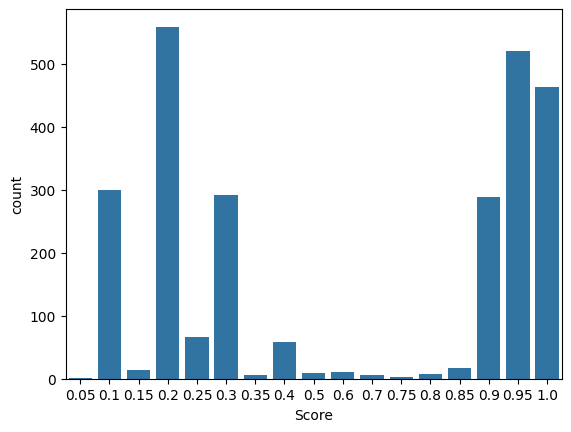

In [12]:
import seaborn as sns

sns.countplot(data=df, x="Score")


## Data Splitting

In [13]:
from sklearn.model_selection import train_test_split

# Get unique questions
unique_questions = df["Question"].unique()

# 80% questions for training, 20% temporary
train_questions, temp_questions = train_test_split(
    unique_questions,
    test_size=0.20,
    random_state=42
)

# Split remaining 20% into validation and test
val_questions, test_questions = train_test_split(
    temp_questions,
    test_size=0.50,
    random_state=42
)

# Create the datasets
train_df = df[df["Question"].isin(train_questions)].copy()
val_df = df[df["Question"].isin(val_questions)].copy()
test_df = df[df["Question"].isin(test_questions)].copy()

print("Training:")
print("Questions:", train_df["Question"].nunique())
print("Responses:", len(train_df))

print("\nValidation:")
print("Questions:", val_df["Question"].nunique())
print("Responses:", len(val_df))

print("\nTest:")
print("Questions:", test_df["Question"].nunique())
print("Responses:", len(test_df))

Training:
Questions: 209
Responses: 2090

Validation:
Questions: 26
Responses: 260

Test:
Questions: 27
Responses: 270


In [14]:
print(
    "Train-Val overlap:",
    len(set(train_questions) & set(val_questions))
)

print(
    "Train-Test overlap:",
    len(set(train_questions) & set(test_questions))
)

print(
    "Val-Test overlap:",
    len(set(val_questions) & set(test_questions))
)

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [15]:
print("TRAIN SCORE DISTRIBUTION")
print(train_df["Score"].value_counts().sort_index())

print("\nVALIDATION SCORE DISTRIBUTION")
print(val_df["Score"].value_counts().sort_index())

print("\nTEST SCORE DISTRIBUTION")
print(test_df["Score"].value_counts().sort_index())

TRAIN SCORE DISTRIBUTION
Score
0.05      1
0.10    242
0.15     12
0.20    446
0.25     54
0.30    231
0.35      5
0.40     46
0.50      8
0.60      9
0.70      6
0.75      2
0.80      6
0.85     13
0.90    230
0.95    415
1.00    364
Name: count, dtype: int64

VALIDATION SCORE DISTRIBUTION
Score
0.10    28
0.15     1
0.20    61
0.25     5
0.30    28
0.35     1
0.40     5
0.80     1
0.90    30
0.95    48
1.00    52
Name: count, dtype: int64

TEST SCORE DISTRIBUTION
Score
0.10    30
0.15     1
0.20    52
0.25     8
0.30    33
0.40     8
0.50     1
0.60     1
0.85     4
0.90    28
0.95    57
1.00    47
Name: count, dtype: int64


In [16]:
def create_messages(row):
    return {
        "messages": [
            {
                "role": "system",
                "content": (
                    "You are a data science subjective answer evaluator. "
                    "Evaluate the student's answer against the question and reference answer. "
                    "Assign a score from 0 to 1."
                )
            },
            {
                "role": "user",
                "content": (
                    f"Question: {row['Question']}\n"
                    f"Reference Answer: {row['Answer']}\n"
                    f"Student Answer: {row['Response']}"
                )
            },
            {
                "role": "assistant",
                "content": f'{{"score": {row["Score"]}}}'
            }
        ]
    }

In [17]:
train_messages = train_df.apply(create_messages, axis=1).tolist()
val_messages = val_df.apply(create_messages, axis=1).tolist()
test_messages = test_df.apply(create_messages, axis=1).tolist()

In [18]:
print(train_messages[0])

{'messages': [{'role': 'system', 'content': "You are a data science subjective answer evaluator. Evaluate the student's answer against the question and reference answer. Assign a score from 0 to 1."}, {'role': 'user', 'content': 'Question: What is data science?\nReference Answer: Data science is an interdisciplinary field that uses scientific methods, processes, algorithms, and systems to extract knowledge and insights from data.\nStudent Answer: Data science is a field that combines statistics, computer science, and domain expertise to extract insights and knowledge from data. It involves various steps like data collection, cleaning, analysis, and visualization. The insights gained are used to support decision-making in businesses and research.'}, {'role': 'assistant', 'content': '{"score": 1.0}'}]}


## Creating HuggingFace Datasets

In [19]:
from datasets import Dataset

train_dataset = Dataset.from_list(train_messages)
val_dataset = Dataset.from_list(val_messages)
test_dataset = Dataset.from_list(test_messages)

In [20]:
print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['messages'],
    num_rows: 2090
})
Dataset({
    features: ['messages'],
    num_rows: 260
})
Dataset({
    features: ['messages'],
    num_rows: 270
})


In [21]:
train_dataset[0]

{'messages': [{'content': "You are a data science subjective answer evaluator. Evaluate the student's answer against the question and reference answer. Assign a score from 0 to 1.",
   'role': 'system'},
  {'content': 'Question: What is data science?\nReference Answer: Data science is an interdisciplinary field that uses scientific methods, processes, algorithms, and systems to extract knowledge and insights from data.\nStudent Answer: Data science is a field that combines statistics, computer science, and domain expertise to extract insights and knowledge from data. It involves various steps like data collection, cleaning, analysis, and visualization. The insights gained are used to support decision-making in businesses and research.',
   'role': 'user'},
  {'content': '{"score": 1.0}', 'role': 'assistant'}]}

In [22]:
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 2090
Validation: 260
Test: 270


In [23]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_name = "Qwen/Qwen3-4B"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Model loaded successfully!")

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Model loaded successfully!


In [24]:
print("Model:", model_name)
print("Device:", model.device)
print("Dtype:", model.dtype)

Model: Qwen/Qwen3-4B
Device: cuda:0
Dtype: torch.bfloat16


## Configure QLoRA

In [25]:
from peft import LoraConfig, prepare_model_for_kbit_training

In [26]:
model = prepare_model_for_kbit_training(model)

In [27]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj"
    ]
)

In [28]:
from peft import get_peft_model

model = get_peft_model(model, lora_config)

In [29]:
model.print_trainable_parameters()

trainable params: 11,796,480 || all params: 4,034,264,576 || trainable%: 0.2924


## Prepare Dataset for Qwen

In [30]:
sample = train_dataset[0]["messages"]

text = tokenizer.apply_chat_template(
    sample,
    tokenize=False,
    add_generation_prompt=False
)

print(text)

<|im_start|>system
You are a data science subjective answer evaluator. Evaluate the student's answer against the question and reference answer. Assign a score from 0 to 1.<|im_end|>
<|im_start|>user
Question: What is data science?
Reference Answer: Data science is an interdisciplinary field that uses scientific methods, processes, algorithms, and systems to extract knowledge and insights from data.
Student Answer: Data science is a field that combines statistics, computer science, and domain expertise to extract insights and knowledge from data. It involves various steps like data collection, cleaning, analysis, and visualization. The insights gained are used to support decision-making in businesses and research.<|im_end|>
<|im_start|>assistant
<think>

</think>

{"score": 1.0}<|im_end|>



In [31]:
def format_example(example):
    return tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False
    )

In [32]:
print(format_example(train_dataset[0]))

<|im_start|>system
You are a data science subjective answer evaluator. Evaluate the student's answer against the question and reference answer. Assign a score from 0 to 1.<|im_end|>
<|im_start|>user
Question: What is data science?
Reference Answer: Data science is an interdisciplinary field that uses scientific methods, processes, algorithms, and systems to extract knowledge and insights from data.
Student Answer: Data science is a field that combines statistics, computer science, and domain expertise to extract insights and knowledge from data. It involves various steps like data collection, cleaning, analysis, and visualization. The insights gained are used to support decision-making in businesses and research.<|im_end|>
<|im_start|>assistant
<think>

</think>

{"score": 1.0}<|im_end|>



In [33]:
train_dataset = train_dataset.map(
    lambda x: {"text": format_example(x)}
)

val_dataset = val_dataset.map(
    lambda x: {"text": format_example(x)}
)

test_dataset = test_dataset.map(
    lambda x: {"text": format_example(x)}
)

Map:   0%|          | 0/2090 [00:00<?, ? examples/s]

Map:   0%|          | 0/260 [00:00<?, ? examples/s]

Map:   0%|          | 0/270 [00:00<?, ? examples/s]

In [34]:
print(train_dataset.column_names)

['messages', 'text']


In [35]:
print(train_dataset[0]["text"])

<|im_start|>system
You are a data science subjective answer evaluator. Evaluate the student's answer against the question and reference answer. Assign a score from 0 to 1.<|im_end|>
<|im_start|>user
Question: What is data science?
Reference Answer: Data science is an interdisciplinary field that uses scientific methods, processes, algorithms, and systems to extract knowledge and insights from data.
Student Answer: Data science is a field that combines statistics, computer science, and domain expertise to extract insights and knowledge from data. It involves various steps like data collection, cleaning, analysis, and visualization. The insights gained are used to support decision-making in businesses and research.<|im_end|>
<|im_start|>assistant
<think>

</think>

{"score": 1.0}<|im_end|>



## Setting Training Parameters

In [36]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./qwen3-answer-evaluator",

    num_train_epochs=3,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,

    gradient_accumulation_steps=8,

    learning_rate=2e-4,

    logging_steps=10,

    eval_strategy="steps",
    eval_steps=100,

    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,

    fp16=True,

    report_to="none",

    gradient_checkpointing=True,

    optim="paged_adamw_8bit"
)

## Creatinf SFT trainer

In [37]:
from trl import SFTTrainer
from trl import SFTConfig

In [38]:
from trl import SFTConfig

sft_config = SFTConfig(
    output_dir="./qwen3-answer-evaluator",

    num_train_epochs=2,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    gradient_accumulation_steps=4,

    learning_rate=2e-4,

    logging_steps=20,

    # Evaluate only once per epoch
    eval_strategy="epoch",

    # Save only once per epoch
    save_strategy="epoch",
    save_total_limit=1,

    bf16=True,
    fp16=False,

    report_to="none",

    gradient_checkpointing=True,

    optim="paged_adamw_8bit",

    dataset_text_field="text",

    max_length=256,

    packing=False
)

In [39]:
trainer = SFTTrainer(
    model=model,

    args=sft_config,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    processing_class=tokenizer
)

Tokenizing train dataset:   0%|          | 0/2090 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/2090 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/2090 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/2090 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/260 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/260 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/260 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/260 [00:00<?, ? examples/s]

In [40]:
print(type(trainer))

<class 'trl.trainer.sft_trainer.SFTTrainer'>


In [41]:
sample_text = train_dataset[0]["text"]

tokens = tokenizer(
    sample_text,
    add_special_tokens=False
)

print("Number of tokens:", len(tokens["input_ids"]))

Number of tokens: 148


In [42]:
for i in range(5):
    tokens = tokenizer(
        train_dataset[i]["text"],
        add_special_tokens=False
    )

    print(f"Example {i}: {len(tokens['input_ids'])} tokens")

Example 0: 148 tokens
Example 1: 158 tokens
Example 2: 180 tokens
Example 3: 174 tokens
Example 4: 142 tokens


In [43]:
lengths = []

for example in train_dataset:
    tokens = tokenizer(
        example["text"],
        add_special_tokens=False
    )
    lengths.append(len(tokens["input_ids"]))

print("Maximum length:", max(lengths))
print("Minimum length:", min(lengths))
print("Average length:", sum(lengths) / len(lengths))

Maximum length: 206
Minimum length: 103
Average length: 138.4712918660287


In [44]:
print("BF16 supported:", torch.cuda.is_bf16_supported())

BF16 supported: True


In [ ]:
trainer.train()

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [46]:
import os

checkpoint_dir = "/content/drive/MyDrive/qwen3-answer-evaluator"

print(os.listdir(checkpoint_dir))

['README.md', 'checkpoint-524']


In [47]:
model_name = "Qwen/Qwen3-4B"

# Set this to your chosen checkpoint folder
adapter_path = os.path.join(checkpoint_dir, "checkpoint-524")

# Use the checkpoint that actually exists in your Drive
print(os.path.isdir(adapter_path))

True


In [49]:
from peft import PeftModel

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=(
        torch.bfloat16 if torch.cuda.is_bf16_supported()
        else torch.float16
    ),
    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

model = PeftModel.from_pretrained(
    base_model,
    adapter_path
)

model.eval()

print("Fine-tuned model loaded successfully!")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Fine-tuned model loaded successfully!


In [50]:
# Get one example from the test dataset
sample = test_dataset[0]

# Use only the system and user messages as input
messages = sample["messages"][:-1]

# Convert messages into Qwen chat format
prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

# Tokenize the prompt
inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(model.device)

# Generate the prediction
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

# Extract only newly generated tokens
new_tokens = outputs[0][inputs["input_ids"].shape[1]:]

prediction = tokenizer.decode(
    new_tokens,
    skip_special_tokens=True
)

print("Model prediction:", prediction)
print("Actual score:", sample["messages"][-1]["content"])

Model prediction: <think>

</think>

{"score": 1.0}
Actual score: {"score": 1.0}


In [51]:
import json
import re
import torch
import pandas as pd

predictions = []
actual_scores = []

for i, sample in enumerate(test_dataset):

    messages = sample["messages"][:-1]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    prediction = tokenizer.decode(
        new_tokens,
        skip_special_tokens=True
    ).strip()

    # Extract score from model output
    match = re.search(r'"score"\s*:\s*(0?\.\d+|1(?:\.0+)?)', prediction)

    if match:
        predicted_score = float(match.group(1))
    else:
        predicted_score = None

    # Get actual score
    actual = float(
        re.search(
            r'"score"\s*:\s*(0?\.\d+|1(?:\.0+)?)',
            sample["messages"][-1]["content"]
        ).group(1)
    )

    predictions.append(predicted_score)
    actual_scores.append(actual)

    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/{len(test_dataset)}")

Processed 10/270
Processed 20/270
Processed 30/270
Processed 40/270
Processed 50/270
Processed 60/270
Processed 70/270
Processed 80/270
Processed 90/270
Processed 100/270
Processed 110/270
Processed 120/270
Processed 130/270
Processed 140/270
Processed 150/270
Processed 160/270
Processed 170/270
Processed 180/270
Processed 190/270
Processed 200/270
Processed 210/270
Processed 220/270
Processed 230/270
Processed 240/270
Processed 250/270
Processed 260/270
Processed 270/270


In [52]:
results_df = pd.DataFrame({
    "Actual": actual_scores,
    "Predicted": predictions
})

print(results_df.head(20))

    Actual  Predicted
0      1.0       1.00
1      1.0       1.00
2      1.0       1.00
3      1.0       1.00
4      1.0       1.00
5      1.0       1.00
6      1.0       0.95
7      1.0       1.00
8      1.0       1.00
9      1.0       1.00
10     1.0       0.95
11     1.0       0.95
12     1.0       1.00
13     1.0       1.00
14     1.0       1.00
15     1.0       1.00
16     1.0       1.00
17     1.0       1.00
18     1.0       1.00
19     1.0       1.00


In [53]:
print("Total test samples:", len(results_df))
print("Valid predictions:", results_df["Predicted"].notna().sum())
print("Failed predictions:", results_df["Predicted"].isna().sum())

Total test samples: 270
Valid predictions: 270
Failed predictions: 0


In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Remove failed predictions
valid_results = results_df.dropna(subset=["Predicted"])

y_true = valid_results["Actual"]
y_pred = valid_results["Predicted"]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("Number of valid predictions:", len(valid_results))
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

Number of valid predictions: 270
MAE:  0.0424
RMSE: 0.0875
R²:   0.9449


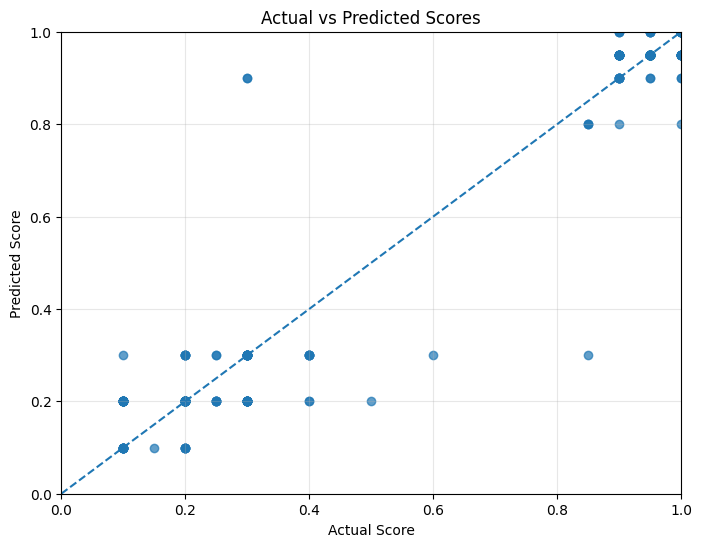

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    results_df["Actual"],
    results_df["Predicted"],
    alpha=0.7
)

# Perfect prediction line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

plt.show()